# Thrivot - Income Affordability: Regression Model

**What this notebook does.** Trains the **regression** half of Thrivot's affordability engine: it predicts the **monthly cost of living** of any U.S. city from independent city characteristics (location, population, crime, weather / disaster risk, area income, household profile). Cost of living is the dollar figure a user's income is later compared against to decide affordability.

**Why it matters for the project.** This model turns raw city data into a single, honest cost number. The income-aware **classification** notebook then compares a user's income to this cost to produce an affordability score.

**Cost target = real rent + everything else.** The target `cost_of_living_monthly` strips MIT's modelled housing figure and substitutes the **real observed Zillow rent**, so rent is the largest component of the number this model predicts.

**Board-ready graphs in this notebook**
1. Target distribution + correlation heatmap - *the data*
2. **Weather risk deep-dive** - *correlation, cost-by-risk-band, and distribution of all 4 FEMA risks*
3. Cross-validation bars - *does it generalise to unseen cities?*
4. **Training curve** (error vs boosting rounds) - *the model learning*
5. Predicted-vs-actual + residuals - *accuracy*

**Honesty note.** R² is very high (~0.99) because cost of living is strongly determined by geography and area income. The **city-grouped split + GroupKFold cross-validation** prove the score holds on cities the model never saw during training.


## 1. Imports

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 5)
print("Libraries loaded.")

Libraries loaded.


## 2. Load data & build the unified cost-of-living target

Fuse MIT non-housing living costs with the **real observed Zillow rent** into one monthly
`cost_of_living_monthly`, in long format (one row per city per family profile).

In [2]:
DATA_PATH = Path("../data/cleaned_data/master_data_clean.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} cities x {df.shape[1]} columns")

PROFILES = ["1p0c", "1p1c", "1p2c", "1p3c", "2p0c", "2p1c", "2p2c"]
PROFILE_ENCODING = {p: i for i, p in enumerate(PROFILES)}

CITY_COLS = [
    "state", "city", "city_state_key", "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "avg_monthly_rent",
]

# MIT total_cost is ANNUAL and contains a modelled housing figure. We remove that and
# substitute the REAL observed Zillow monthly rent, so the target fuses every dataset.
frames = []
for p in PROFILES:
    block = df[CITY_COLS].copy()
    monthly_non_housing = (df[f"{p}_total_cost"] - df[f"{p}_housing_cost"]) / 12.0
    block["cost_of_living_monthly"] = monthly_non_housing + df["avg_monthly_rent"]
    block["family_profile"] = p
    block["family_profile_encoded"] = PROFILE_ENCODING[p]
    frames.append(block)
long_df = pd.concat(frames, ignore_index=True)

print(f"Long dataset: {long_df.shape[0]:,} rows ({df.shape[0]:,} cities x {len(PROFILES)} profiles)")
print(long_df["cost_of_living_monthly"].describe().round(0))

Loaded 27,441 cities x 73 columns
Long dataset: 192,087 rows (27,441 cities x 7 profiles)
count    192087.0
mean       6193.0
std        2149.0
min        2794.0
25%        4866.0
50%        5956.0
75%        7013.0
max       27493.0
Name: cost_of_living_monthly, dtype: float64


## 3. Exploratory analysis & correlation

The heatmap shows which characteristics move with cost; the histogram shows the target's shape.
`avg_monthly_rent` correlates almost perfectly because it is *part of* the target - which is
exactly why it is excluded from the model inputs in the next section.

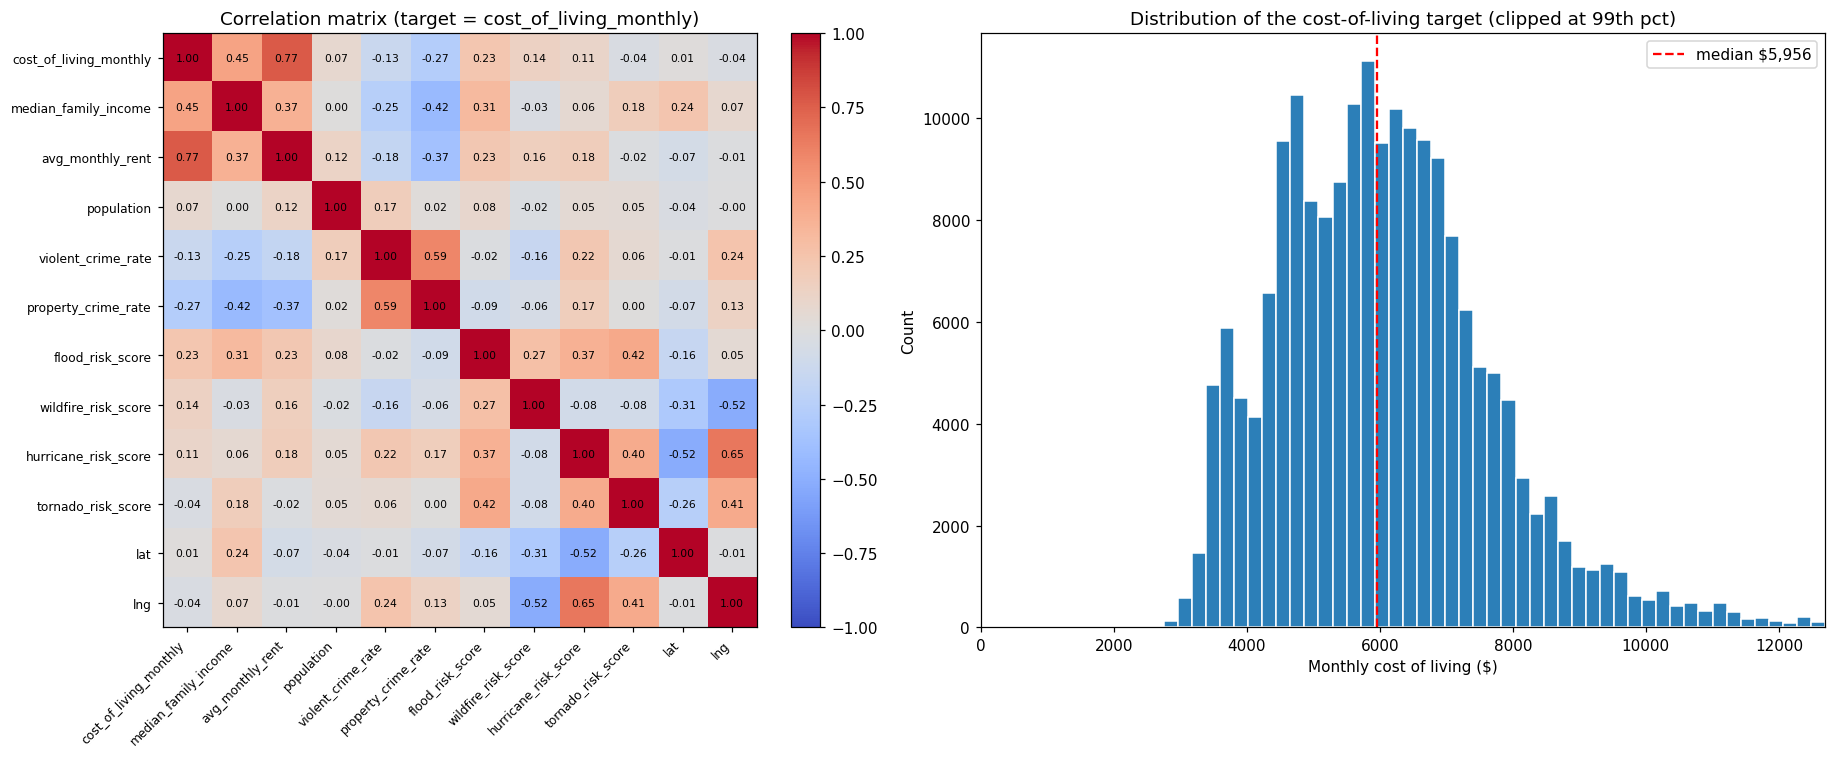

Correlation of each variable with the target:
avg_monthly_rent        0.773
median_family_income    0.448
flood_risk_score        0.228
wildfire_risk_score     0.136
hurricane_risk_score    0.107
population              0.071
lat                     0.009
tornado_risk_score     -0.037
lng                    -0.039
violent_crime_rate     -0.134
property_crime_rate    -0.273
Name: cost_of_living_monthly, dtype: float64


In [11]:
EDA_COLS = [
    "cost_of_living_monthly", "median_family_income", "avg_monthly_rent",
    "population", "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score", "hurricane_risk_score",
    "tornado_risk_score", "lat", "lng",
]
corr = long_df[EDA_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
im = axes[0].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(EDA_COLS)))
axes[0].set_yticks(range(len(EDA_COLS)))
axes[0].set_xticklabels(EDA_COLS, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(EDA_COLS, fontsize=8)
for i in range(len(EDA_COLS)):
    for j in range(len(EDA_COLS)):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[0].set_title("Correlation matrix (target = cost_of_living_monthly)")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Clip the x-axis at the 99th percentile so a handful of ultra-expensive cities
# (e.g. luxury resort towns) don't stretch the plot and make it look broken.
median_cost = long_df["cost_of_living_monthly"].median()
hist_clip = long_df["cost_of_living_monthly"].quantile(0.99)
axes[1].hist(long_df["cost_of_living_monthly"], bins=60, range=(0, hist_clip),
             color="#2c7fb8", edgecolor="white")
axes[1].axvline(median_cost, color="red", linestyle="--", label=f"median ${median_cost:,.0f}")
axes[1].set_xlim(0, hist_clip)
axes[1].set_xlabel("Monthly cost of living ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of the cost-of-living target (clipped at 99th pct)")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Correlation of each variable with the target:")
print(corr["cost_of_living_monthly"].drop("cost_of_living_monthly").sort_values(ascending=False).round(3))


## 3b. Weather risk deep-dive

A focused look at the four FEMA National Risk Index scores (flood, wildfire, hurricane, tornado)
and how they relate to cost of living. Three views:

1. **Weather-only correlation heatmap** - how the four risks relate to each other and to cost.
2. **Cost of living across weather-risk bands** - mean cost as each risk goes from low to high.
3. **Distribution of each risk score** - how the scores are spread across U.S. cities.


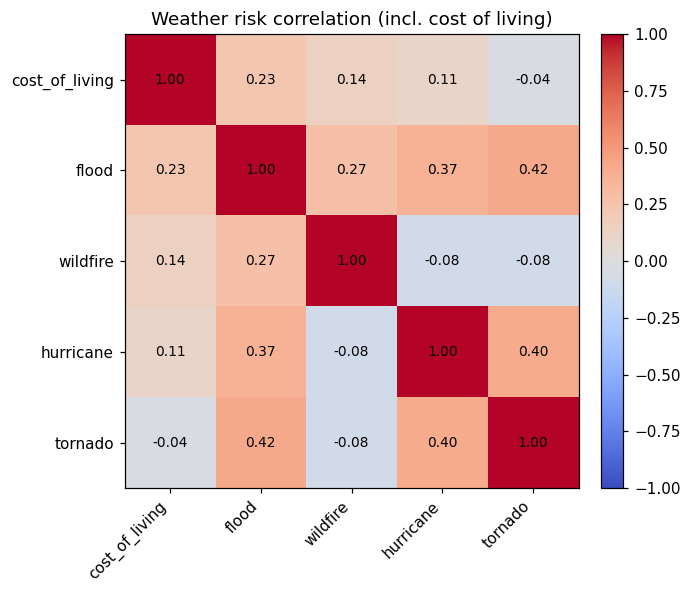

Correlation of each weather risk with cost of living:
flood_risk_score        0.228
wildfire_risk_score     0.136
hurricane_risk_score    0.107
tornado_risk_score     -0.037
Name: cost_of_living_monthly, dtype: float64


In [13]:
WEATHER_COLS = ["flood_risk_score", "wildfire_risk_score",
                "hurricane_risk_score", "tornado_risk_score"]

# --- Weather graph 1: weather-only correlation heatmap (incl. cost of living) ---
w_corr = long_df[["cost_of_living_monthly"] + WEATHER_COLS].corr()
labels = ["cost_of_living"] + [c.replace("_risk_score", "") for c in WEATHER_COLS]

plt.figure(figsize=(6.5, 5.5))
im = plt.imshow(w_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{w_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.title("Weather risk correlation (incl. cost of living)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Correlation of each weather risk with cost of living:")
print(w_corr["cost_of_living_monthly"].drop("cost_of_living_monthly")
      .sort_values(ascending=False).round(3))


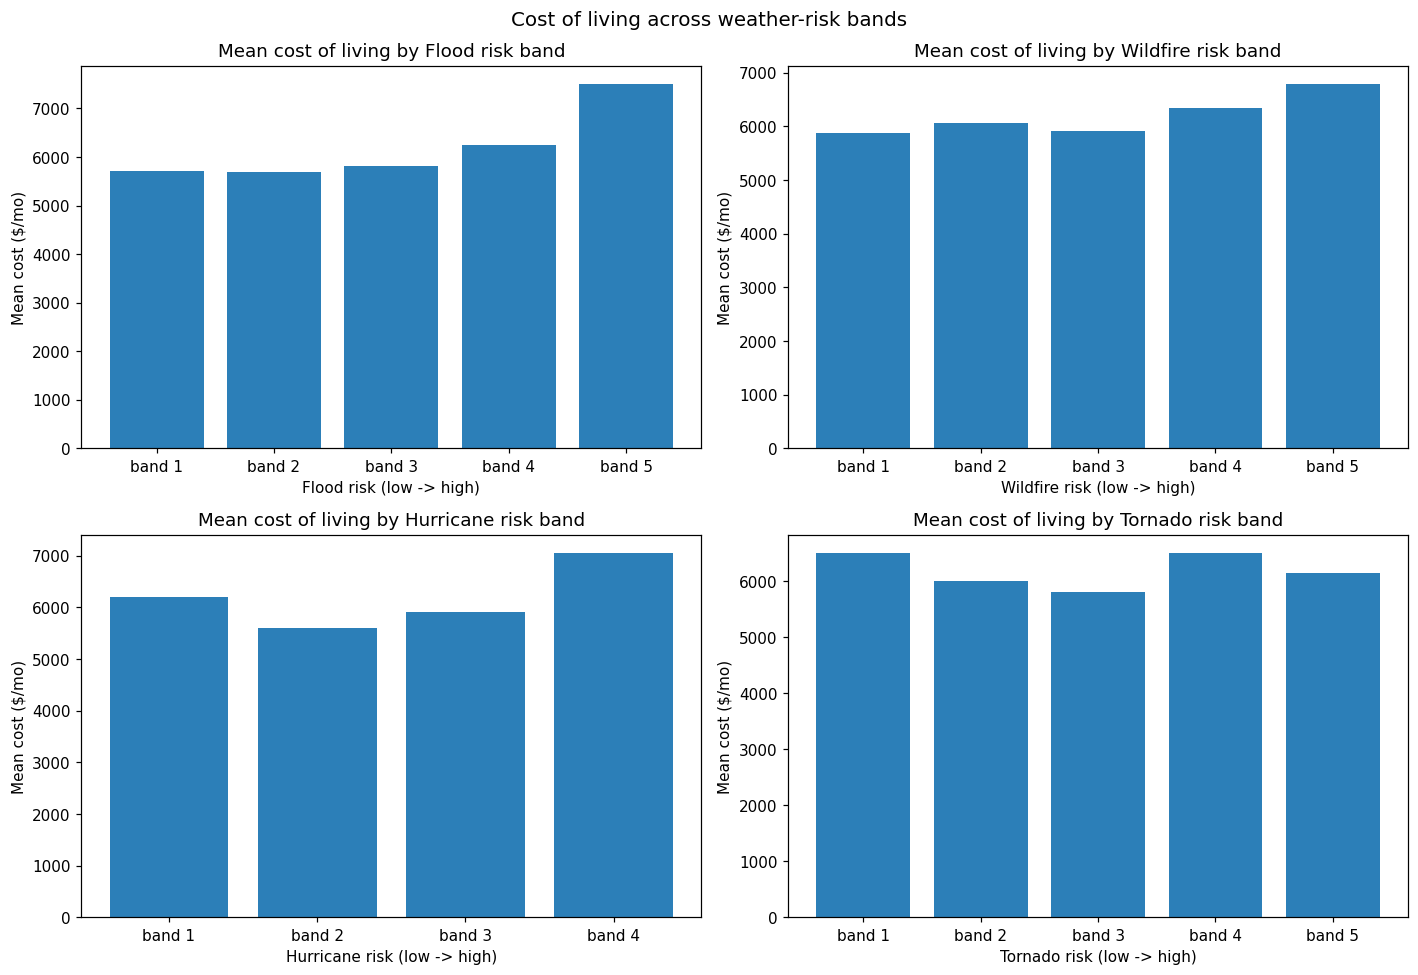

In [14]:
# --- Weather graph 2: does cost of living move with each weather risk? ---
# Split each risk score into 5 equal-size bands (low -> high) and show the
# average cost of living in each band, so the trend is easy to read.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), WEATHER_COLS):
    name = col.replace("_risk_score", "").title()
    bands = pd.qcut(long_df[col], q=5, duplicates="drop")
    grp = long_df.groupby(bands, observed=True)["cost_of_living_monthly"].mean()
    xlabels = [f"band {i+1}" for i in range(len(grp))]
    ax.bar(xlabels, grp.values, color="#2c7fb8")
    ax.set_title(f"Mean cost of living by {name} risk band")
    ax.set_xlabel(f"{name} risk (low -> high)")
    ax.set_ylabel("Mean cost ($/mo)")
fig.suptitle("Cost of living across weather-risk bands", fontsize=13)
plt.tight_layout()
plt.show()


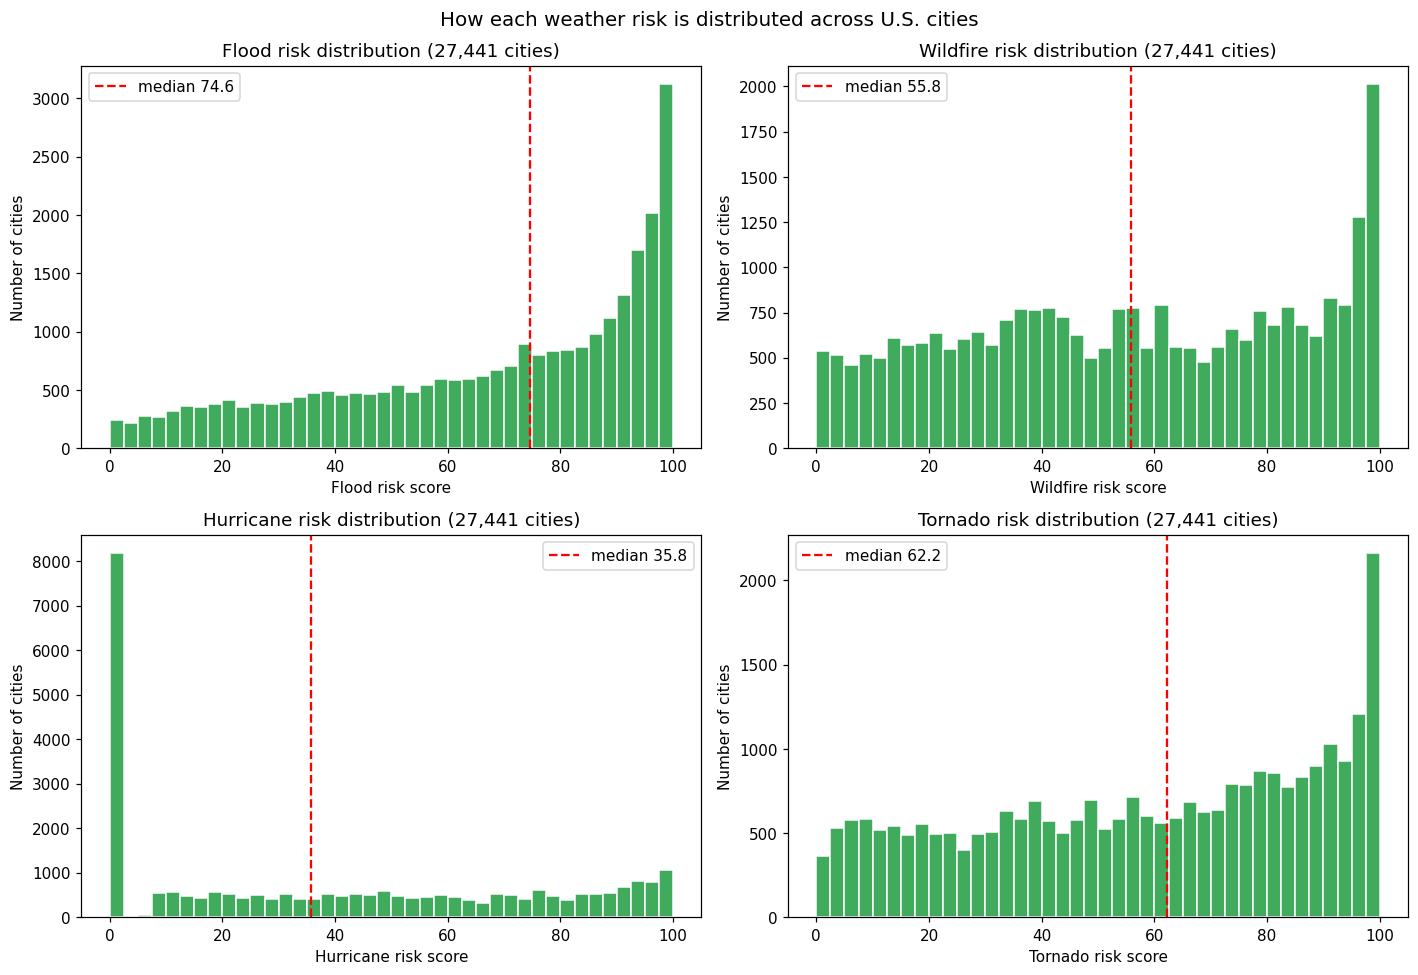

In [15]:
# --- Weather graph 3: how each risk score is spread across U.S. cities ---
# Use df (one row per city) so cities aren't counted 7x (once per family profile).
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), WEATHER_COLS):
    name = col.replace("_risk_score", "").title()
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#41ab5d", edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--",
               label=f"median {data.median():.1f}")
    ax.set_title(f"{name} risk distribution ({len(data):,} cities)")
    ax.set_xlabel(f"{name} risk score")
    ax.set_ylabel("Number of cities")
    ax.legend()
fig.suptitle("How each weather risk is distributed across U.S. cities", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Features & target (leakage-free)

Inputs are **independent city characteristics only**. We exclude `avg_monthly_rent` and every MIT
cost component because those are baked into the target - using them would be circular. Crime and
population are only reported for ~3% of cities, but XGBoost handles their missing values natively.

In [4]:
FEATURE_COLS = [
    "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "family_profile_encoded",
]
TARGET = "cost_of_living_monthly"

REQUIRED = [TARGET, "median_family_income", "lat", "lng",
            "flood_risk_score", "wildfire_risk_score",
            "hurricane_risk_score", "tornado_risk_score"]
model_df = long_df.dropna(subset=REQUIRED).reset_index(drop=True)
print(f"Rows kept: {model_df.shape[0]:,} of {long_df.shape[0]:,}")
print(f"Crime / population coverage (non-null): {model_df['violent_crime_rate'].notna().mean():.1%} of rows")

Rows kept: 192,087 of 192,087
Crime / population coverage (non-null): 3.1% of rows


## 5. City-grouped train / test split

Every city has 7 profile rows. A random split would leak a city into both sets, so we split by
**city group** - each city is entirely in train or test. This is the honest way to measure
generalisation to *new* places.

In [5]:
groups = model_df["city_state_key"]
X = model_df[FEATURE_COLS]
y = model_df[TARGET]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}")
print(f"Cities shared between train and test: {len(overlap)} (must be 0)")

Train rows: 153,629 | Test rows: 38,458
Cities shared between train and test: 0 (must be 0)


## 6. Cross-validation (does it generalise?)

We cross-validate with **GroupKFold** so every fold is scored on cities it never saw during
training. Near-identical bars across folds means the model is stable, not lucky.

GroupKFold R^2 per fold: [0.987 0.988 0.988 0.988]
Mean CV R^2 = 0.988  (+/- 0.000)


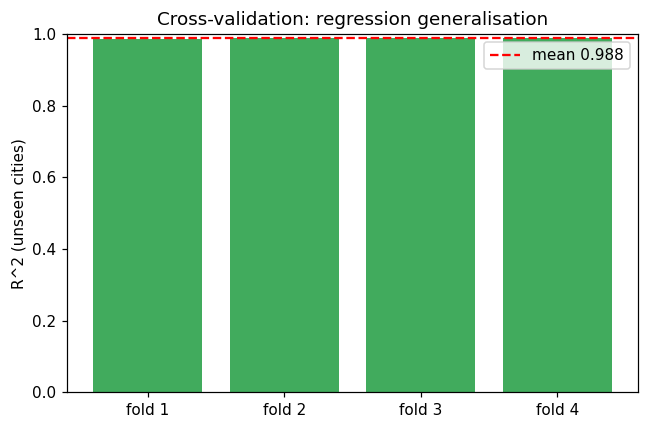

In [6]:
def make_regressor():
    return XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

gkf = GroupKFold(n_splits=4)
cv_r2 = cross_val_score(make_regressor(), X_train, y_train,
                        groups=groups_train, cv=gkf, scoring="r2", n_jobs=-1)
print("GroupKFold R^2 per fold:", np.round(cv_r2, 3))
print(f"Mean CV R^2 = {cv_r2.mean():.3f}  (+/- {cv_r2.std():.3f})")

plt.figure(figsize=(6, 4))
plt.bar([f"fold {i+1}" for i in range(len(cv_r2))], cv_r2, color="#41ab5d")
plt.axhline(cv_r2.mean(), color="red", linestyle="--", label=f"mean {cv_r2.mean():.3f}")
plt.ylim(0, 1)
plt.ylabel("R^2 (unseen cities)")
plt.title("Cross-validation: regression generalisation")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train the final model + training curve

We fit the final model on all training rows while recording the error at **every boosting round**
for both the training set and the held-out validation set. The resulting curve is the classic
"model learning" graph for a research board - error falls and then flattens as trees are added.

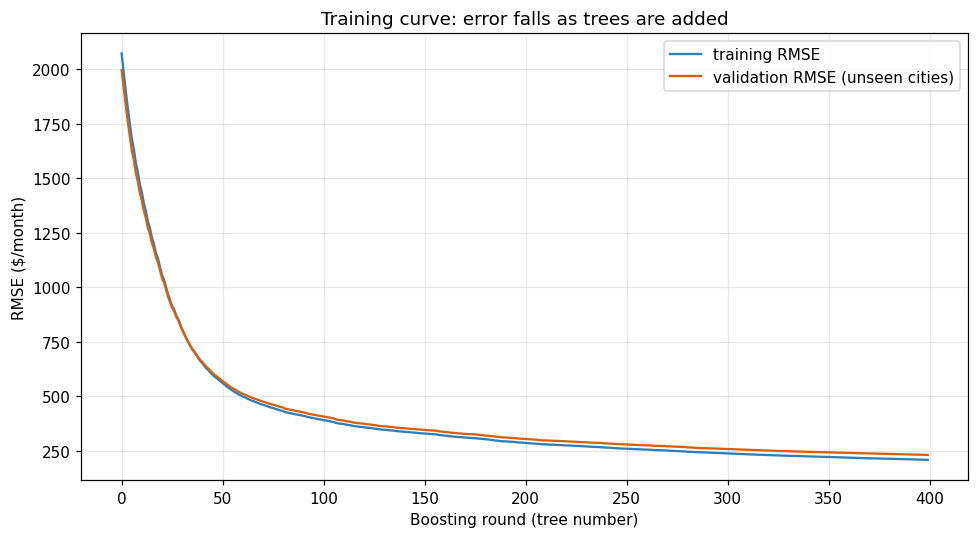

Final training RMSE:   $207/mo
Final validation RMSE: $230/mo


In [7]:
# Train the final model while recording train vs validation RMSE at every boosting round.
model = make_regressor()
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
results = model.evals_result()
train_rmse = results["validation_0"]["rmse"]
test_rmse = results["validation_1"]["rmse"]

plt.figure(figsize=(9, 5))
plt.plot(train_rmse, label="training RMSE", color="#2c7fb8")
plt.plot(test_rmse, label="validation RMSE (unseen cities)", color="#d95f0e")
plt.xlabel("Boosting round (tree number)")
plt.ylabel("RMSE ($/month)")
plt.title("Training curve: error falls as trees are added")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training RMSE:   ${train_rmse[-1]:,.0f}/mo")
print(f"Final validation RMSE: ${test_rmse[-1]:,.0f}/mo")

## 8. Evaluate on unseen cities

Predicted-vs-actual should hug the diagonal; residuals should center on zero with no skew.

Regression performance on UNSEEN cities:
  R^2  = 0.988
  RMSE = $230 / month
  MAE  = $158 / month
  (target median = $5,938 / month)


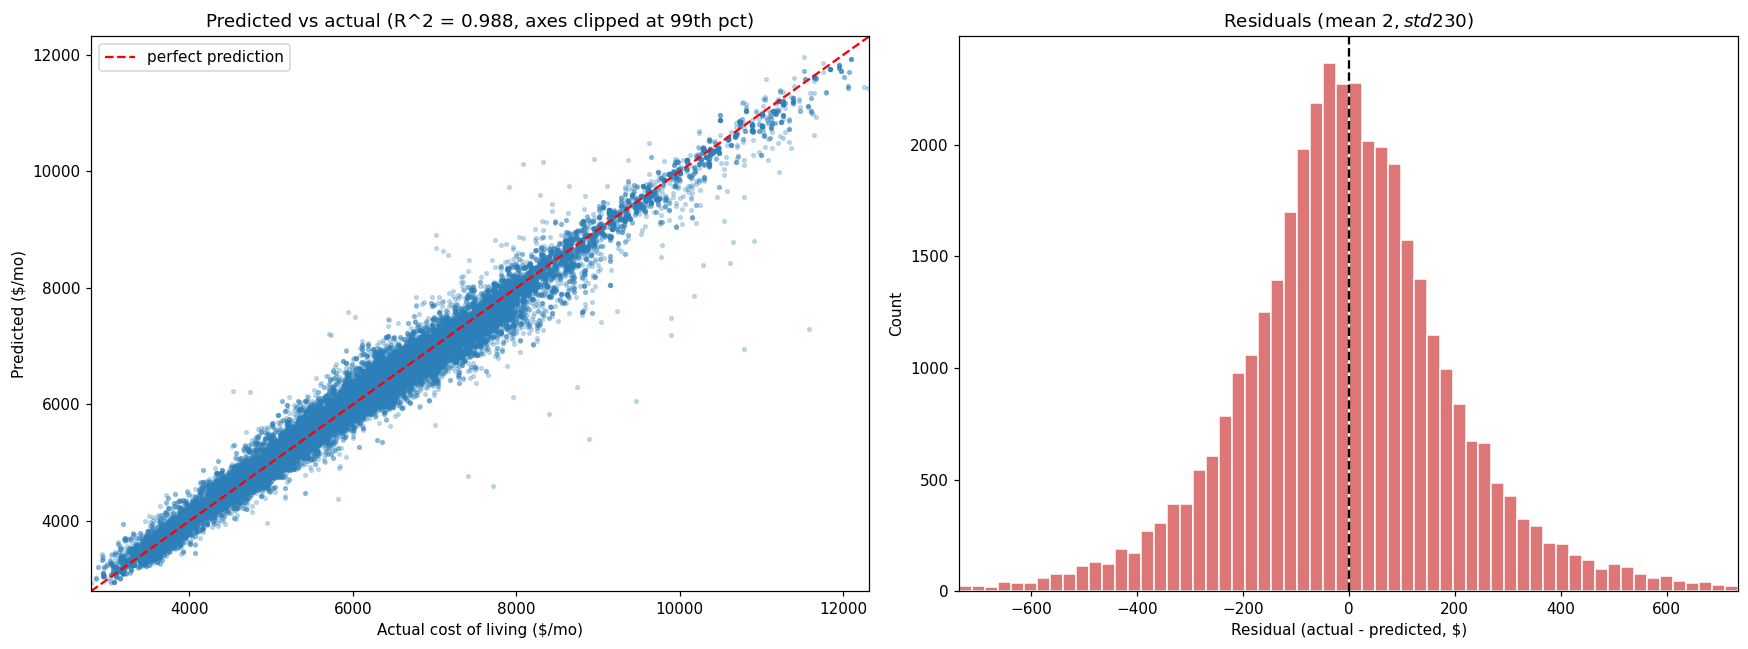

In [12]:
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Regression performance on UNSEEN cities:")
print(f"  R^2  = {r2:.3f}")
print(f"  RMSE = ${rmse:,.0f} / month")
print(f"  MAE  = ${mae:,.0f} / month")
print(f"  (target median = ${y_test.median():,.0f} / month)")

residuals = y_test.values - pred
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clip both axes at the 99th percentile so a few very expensive cities don't
# stretch the frame; the bulk of the data fills the plot instead.
hi = float(np.percentile(np.concatenate([y_test.values, pred]), 99))
lo = float(min(y_test.min(), pred.min()))
lims = [lo, hi]
axes[0].scatter(y_test, pred, s=6, alpha=0.25, color="#2c7fb8")
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual cost of living ($/mo)")
axes[0].set_ylabel("Predicted ($/mo)")
axes[0].set_title(f"Predicted vs actual (R^2 = {r2:.3f}, axes clipped at 99th pct)")
axes[0].legend()

res_clip = float(np.percentile(np.abs(residuals), 99))
axes[1].hist(residuals, bins=60, range=(-res_clip, res_clip),
             color="#dd7777", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlim(-res_clip, res_clip)
axes[1].set_xlabel("Residual (actual - predicted, $)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals (mean ${residuals.mean():,.0f}, std ${residuals.std():,.0f})")
plt.tight_layout()
plt.show()


## 10. Save the model

Persist the cost regression model and its metrics. `model_cost.pkl` is loaded by the
**income classification** notebook and by the FastAPI backend.

In [10]:
joblib.dump(model, "model_cost.pkl")
schema = {
    "feature_cols": FEATURE_COLS,
    "target": TARGET,
    "profile_encoding": PROFILE_ENCODING,
    "regression_metrics": {"r2": round(float(r2), 4),
                           "rmse": round(float(rmse), 2),
                           "mae": round(float(mae), 2)},
    "note": "Cost-of-living regression. Target fuses MIT non-housing costs with observed "
            "Zillow rent; inputs exclude all cost components to avoid leakage.",
}
with open("features_regression.json", "w") as fobj:
    json.dump(schema, fobj, indent=2)
print("Saved model_cost.pkl and features_regression.json")

Saved model_cost.pkl and features_regression.json
